# GeoPAS Failure Analysis

This notebook rebuilds the failure-analysis workflow directly from the seed-aggregated run artifacts instead of reusing derived notebook state.

It:
- loads `relert.csv` plus seed-aggregated protocol-specific `preds_*.csv.gz` files for `LIO`, `Random`, and `LPO`
- reconstructs realised per-row GeoPAS, SBS, and VBS outcomes
- regenerates the requested figures and CSV summaries
- validates the summary CSV tables and the SBS-non-improving subset

The `res_*.csv` files at the run-directory root are used only as validation targets. All realised quantities are rebuilt from `relert.csv` and the seed-aggregated prediction files.

In [1]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import re

try:
    from analyses.analysis_utils import (
        DIM_ORDER as DEFAULT_DIM_ORDER,
        PROBLEM_GROUP_ORDER as DEFAULT_PROBLEM_GROUP_ORDER,
        build_protocol_paths as build_protocol_paths_from_results,
        fgroup_from_problem,
        parse_result_csv_tables,
        resolve_geopas_paths,
    )
except ModuleNotFoundError:
    from analysis_utils import (
        DIM_ORDER as DEFAULT_DIM_ORDER,
        PROBLEM_GROUP_ORDER as DEFAULT_PROBLEM_GROUP_ORDER,
        build_protocol_paths as build_protocol_paths_from_results,
        fgroup_from_problem,
        parse_result_csv_tables,
        resolve_geopas_paths,
    )

FIGURE_FACE = "#f9f8f5"
AXES_FACE = "#ffffff"
GRID_COLOR = "#ddd4c6"
TEXT_COLOR = "#332c26"
GEOPAS_COLOR = "#4b84a0"
GEOPAS_EDGE = "#1f5873"
SBS_COLOR = "#d79b59"
SBS_EDGE = "#e19c2d"
VBS_COLOR = "#9ac9e2"
VBS_EDGE = "#839AB1"
EMPTY_NOTE_COLOR = "#8e8172"

DIM_HIST_COLORS = {
    2: "#8fb9aa",
    3: "#d4aa5f",
    5: "#cc7a5b",
    10: "#8c6aa8",
}
FGROUP_HIST_COLORS = {
    "f1-f5": "#4b84a0",
    "f6-f9": "#7aa05b",
    "f10-f14": "#d4aa5f",
    "f15-f19": "#c7775b",
    "f20-f24": "#8c6aa8",
}
NON_IMPROVING_HIST_COLORS = {
    "Other cells": "#c9d3dd",
    "In EXPECTED_NON_IMPROVING_CELLS": "#c7775b",
}

plt.rcParams.update(
    {
        "figure.dpi": 140,
        "savefig.dpi": 300,
        "figure.facecolor": FIGURE_FACE,
        "savefig.facecolor": FIGURE_FACE,
        "axes.facecolor": AXES_FACE,
        "axes.edgecolor": "#665c50",
        "axes.labelcolor": TEXT_COLOR,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "axes.titleweight": "semibold",
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "font.family": "DejaVu Serif",
        "text.color": TEXT_COLOR,
        "xtick.color": TEXT_COLOR,
        "ytick.color": TEXT_COLOR,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 13,
        "legend.frameon": True,
        "legend.fancybox": False,
        "legend.facecolor": AXES_FACE,
        "legend.edgecolor": GRID_COLOR,
        "lines.linewidth": 2.2,
    }
)

ALG_COLS = [
    "BrentSTEPqi_Posik",
    "BrentSTEPrr_Posik",
    "CMA-CSA_Atamna",
    "HCMA_loshchilov_noiseless",
    "HMLSL_pal_noiseless",
    "IPOP400D_auger_noiseless",
    "MCS_huyer_noiseless",
    "M_LSL_pal_noiseless",
    "OQNLP_pal_noiseless",
    "SMAC-BBOB_hutter_noiseless",
    "fmincon_pal_noiseless",
    "fminunc_pal_noiseless",
]

PROBLEM_GROUP_ORDER = list(DEFAULT_PROBLEM_GROUP_ORDER)
DIM_ORDER = list(DEFAULT_DIM_ORDER)

EXPECTED_NON_IMPROVING_CELLS = {
    ("f1-f5", 3),
    ("f1-f5", 5),
    ("f1-f5", 10),
    ("f15-f19", 3),
    ("f15-f19", 5),
    ("f20-f24", 3),
}

PATHS = resolve_geopas_paths()
WORKSPACE_ROOT = PATHS.workspace_root
PROJECT_ROOT = PATHS.project_root

@dataclass(frozen=True)
class AnalysisConfig:
    repo_root: Path = PROJECT_ROOT
    workspace_root: Path = WORKSPACE_ROOT
    results_bundle: str = "results"
    parameter_set: str = "scalelog_power_head2scalenorm_sigmoidlogs1.0_dual0_head2lw0.0_head2sw0.0_priorscalelog_power_lamprior0.5_tailscale1.0"
    # protocols: tuple[str, ...] = ("LIO", "Random", "LPO")
    protocols: tuple[str, ...] = ("LIO", "LPO")
    # protocols: tuple[str, ...] = ("Random",)
    random_split_seed: int = 17
    res: int = 8
    k_views: int = 32
    float_tol: float = 1e-9
    csv_compare_tol: float = 5e-4
    strict_target_count_validation: bool = False

    @property
    def label_path(self) -> Path:
        return self.repo_root / "data" / "bbob_by_deepela" / "relert.csv"

    @property
    def bbob_root(self) -> Path:
        return self.repo_root / "results" / "bbob_by_deepela" / self.results_bundle / "bbob"

    @property
    def output_dir(self) -> Path:
        return (
            self.workspace_root
            / "analysis_outputs"
            / "failure_analysis"
            / f"{self.parameter_set}__aggregated_over_seeds__randomsplit{self.random_split_seed}__res{self.res}__k{self.k_views}"
        )

config = AnalysisConfig()
config.output_dir.mkdir(parents=True, exist_ok=True)
hist_count_scale = "log"           # Options: "log", "raw"
hist_color_by = 'none'    # Options: "non_improving" "dim", "'fgroup'", "none"
hist_group_target = "geopas"       # Options: "geopas", "sbs", "both"

print("Result scope: aggregated_over_seeds")
print(f"Workspace root: {config.workspace_root}")
print(f"Project root: {config.repo_root}")
print(f"Parameter set: {config.parameter_set}")
print(f"Protocols: {config.protocols}")
print(f"Random split seed: {config.random_split_seed}")
print(f"Histogram count scale: {hist_count_scale}")
print(f"Histogram colour grouping: {hist_color_by}")
print(f"Histogram grouped target: {hist_group_target}")
print(f"Label path: {config.label_path}")
print(f"Output directory: {config.output_dir}")

Result scope: aggregated_over_seeds
Workspace root: /data1/home/jw1017/AS_BBO_REBUILT/GeoPAS_v1
Project root: /data1/home/jw1017/AS_BBO_REBUILT
Parameter set: scalelog_power_head2scalenorm_sigmoidlogs1.0_dual0_head2lw0.0_head2sw0.0_priorscalelog_power_lamprior0.5_tailscale1.0
Protocols: ('LIO', 'LPO')
Random split seed: 17
Histogram count scale: log
Histogram colour grouping: none
Histogram grouped target: geopas
Label path: /data1/home/jw1017/AS_BBO_REBUILT/data/bbob_by_deepela/relert.csv
Output directory: /data1/home/jw1017/AS_BBO_REBUILT/GeoPAS_v1/analysis_outputs/failure_analysis/scalelog_power_head2scalenorm_sigmoidlogs1.0_dual0_head2lw0.0_head2sw0.0_priorscalelog_power_lamprior0.5_tailscale1.0__aggregated_over_seeds__randomsplit17__res8__k32


## Utility Functions

The next cells define reusable helpers for loading files, reconstructing realised outcomes, aggregating summaries, plotting, and validating against the `res_*.csv` files.

In [2]:
def build_protocol_paths(config: AnalysisConfig, protocol: str) -> dict[str, Path]:
    return build_protocol_paths_from_results(
        results_root=config.bbob_root,
        protocol=protocol,
        parameter_set=config.parameter_set,
        res=config.res,
        k_views=config.k_views,
    )


def ensure_algorithm_columns(df: pd.DataFrame, meta_cols: list[str], file_label: str) -> None:
    actual = [col for col in df.columns if col not in meta_cols]
    if actual != ALG_COLS:
        raise ValueError(
            f"{file_label} algorithm columns do not match the expected ordering.\n"
            f"Expected: {ALG_COLS}\nActual:   {actual}"
        )


def load_relert_table(config: AnalysisConfig) -> pd.DataFrame:
    label_df = pd.read_csv(config.label_path)
    label_df["Problem"] = label_df["Problem"].astype(str).str.lower()
    label_df["Dim"] = label_df["Dim"].astype(int)
    ensure_algorithm_columns(label_df, ["Problem", "Dim"], str(config.label_path))
    if len(label_df) != 96:
        raise ValueError(f"Expected 96 label rows, found {len(label_df)}")
    return label_df


def load_prediction_table(pred_path: Path) -> pd.DataFrame:
    pred_df = pd.read_csv(pred_path)
    pred_df["Problem"] = pred_df["Problem"].astype(str).str.lower()
    pred_df["Dim"] = pred_df["Dim"].astype(int)
    pred_df["Instance"] = pred_df["Instance"].astype(int)
    pred_df["Repetition"] = pred_df["Repetition"].astype(int)
    ensure_algorithm_columns(pred_df, ["Problem", "Dim", "Instance", "Repetition"], str(pred_path))
    if len(pred_df) != 4800:
        raise ValueError(f"Expected 4800 prediction rows in {pred_path.name}, found {len(pred_df)}")
    return pred_df


def compute_sbs_algorithm(label_df: pd.DataFrame) -> str:
    return label_df[ALG_COLS].mean(axis=0).idxmin()


def build_label_baseline_frame(label_df: pd.DataFrame, sbs_alg: str) -> pd.DataFrame:
    baseline_df = label_df[["Problem", "Dim"]].copy()
    baseline_df["FGroup"] = baseline_df["Problem"].map(fgroup_from_problem)
    baseline_df["sbs_alg"] = sbs_alg
    baseline_df["sbs_score"] = label_df[sbs_alg].to_numpy(dtype=float)
    baseline_df["vbs_alg"] = label_df[ALG_COLS].idxmin(axis=1)
    baseline_df["vbs_score"] = label_df[ALG_COLS].min(axis=1).to_numpy(dtype=float)
    return baseline_df


def validate_prediction_alignment(pred_df: pd.DataFrame, label_df: pd.DataFrame) -> pd.DataFrame:
    aligned = pred_df[["Problem", "Dim", "Instance", "Repetition"]].merge(
        label_df[["Problem", "Dim"] + ALG_COLS],
        on=["Problem", "Dim"],
        how="left",
        validate="many_to_one",
    )
    if aligned[ALG_COLS].isna().any().any():
        missing = aligned.loc[aligned[ALG_COLS].isna().any(axis=1), ["Problem", "Dim"]].drop_duplicates()
        raise ValueError(
            "Prediction rows could not be aligned to relert.csv on (Problem, Dim).\n"
            f"Missing keys:\n{missing.to_string(index=False)}"
        )
    return aligned


def build_protocol_analysis_df(protocol: str, label_df: pd.DataFrame, config: AnalysisConfig) -> tuple[pd.DataFrame, dict[str, Path]]:
    paths = build_protocol_paths(config, protocol)
    pred_df = load_prediction_table(paths["pred"])
    aligned = validate_prediction_alignment(pred_df, label_df)

    pred_mat = pred_df[ALG_COLS].to_numpy(dtype=float)
    true_mat = aligned[ALG_COLS].to_numpy(dtype=float)
    alg_array = np.array(ALG_COLS, dtype=object)

    as_idx = pred_mat.argmin(axis=1)
    scratch = pred_mat.copy()
    scratch[np.arange(len(scratch)), as_idx] = np.inf
    second_idx = scratch.argmin(axis=1)

    sbs_alg = compute_sbs_algorithm(label_df)
    sbs_idx = ALG_COLS.index(sbs_alg)
    vbs_idx = true_mat.argmin(axis=1)

    protocol_df = pred_df[["Problem", "Dim", "Instance", "Repetition"]].copy()
    protocol_df["Protocol"] = protocol
    protocol_df["FGroup"] = protocol_df["Problem"].map(fgroup_from_problem)
    protocol_df["as_alg"] = alg_array[as_idx]
    protocol_df["predicted_as_score"] = pred_mat[np.arange(len(pred_mat)), as_idx]
    protocol_df["predicted_margin"] = pred_mat[np.arange(len(pred_mat)), second_idx] - pred_mat[np.arange(len(pred_mat)), as_idx]
    protocol_df["as_score"] = true_mat[np.arange(len(true_mat)), as_idx]
    protocol_df["sbs_alg"] = sbs_alg
    protocol_df["sbs_score"] = true_mat[:, sbs_idx]
    protocol_df["vbs_alg"] = alg_array[vbs_idx]
    protocol_df["vbs_score"] = true_mat[np.arange(len(true_mat)), vbs_idx]
    return protocol_df, paths


def reduce_values(values: np.ndarray, metric: str) -> float:
    values = np.asarray(values, dtype=float)
    if metric == "Mean":
        return float(np.mean(values))
    if metric == "Median":
        return float(np.median(values))
    if metric == "P90":
        return float(np.quantile(values, 0.9))
    raise ValueError(f"Unsupported metric: {metric}")


def build_metric_table(frame: pd.DataFrame, value_col: str, metric: str) -> pd.DataFrame:
    rows = []
    for group in PROBLEM_GROUP_ORDER:
        row = {"Problem Group": group}
        group_mask = np.ones(len(frame), dtype=bool) if group == "all" else frame["FGroup"].to_numpy() == group
        for dim in DIM_ORDER:
            dim_mask = np.ones(len(frame), dtype=bool) if dim == "all" else frame["Dim"].to_numpy() == int(dim)
            subset = frame.loc[group_mask & dim_mask, value_col].to_numpy(dtype=float)
            row[dim] = reduce_values(subset, metric)
        rows.append(row)
    return pd.DataFrame(rows)


def build_protocol_cell_summary(protocol_df: pd.DataFrame) -> pd.DataFrame:
    grouped = protocol_df.groupby(["FGroup", "Dim"], as_index=False)
    return grouped.agg(
        row_count=("as_score", "size"),
        as_mean=("as_score", "mean"),
        as_median=("as_score", "median"),
        as_p90=("as_score", lambda values: np.quantile(values, 0.9)),
        sbs_mean=("sbs_score", "mean"),
        sbs_median=("sbs_score", "median"),
        sbs_p90=("sbs_score", lambda values: np.quantile(values, 0.9)),
        vbs_mean=("vbs_score", "mean"),
        vbs_median=("vbs_score", "median"),
        vbs_p90=("vbs_score", lambda values: np.quantile(values, 0.9)),
    )


def build_protocol_level_summary(protocol: str, protocol_df: pd.DataFrame, label_baseline_df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {
                "Protocol": protocol,
                "as_mean": protocol_df["as_score"].mean(),
                "as_median": protocol_df["as_score"].median(),
                "as_p90": np.quantile(protocol_df["as_score"], 0.9),
                "sbs_mean_broadcast": protocol_df["sbs_score"].mean(),
                "sbs_median_broadcast": protocol_df["sbs_score"].median(),
                "sbs_p90_broadcast": np.quantile(protocol_df["sbs_score"], 0.9),
                "sbs_mean_legacy": label_baseline_df["sbs_score"].mean(),
                "sbs_median_legacy": label_baseline_df["sbs_score"].median(),
                "sbs_p90_legacy": np.quantile(label_baseline_df["sbs_score"], 0.9),
                "vbs_mean": protocol_df["vbs_score"].mean(),
                "vbs_median": protocol_df["vbs_score"].median(),
                "vbs_p90": np.quantile(protocol_df["vbs_score"], 0.9),
            }
        ]
    )


def compute_non_improving_cells(cell_summary_df: pd.DataFrame, tol: float) -> set[tuple[str, int]]:
    pivot = cell_summary_df.pivot_table(index=["FGroup", "Dim"], columns="Protocol", values=["as_p90", "sbs_p90"])
    keep_mask = np.ones(len(pivot), dtype=bool)
    for protocol in config.protocols:
        keep_mask &= pivot[("as_p90", protocol)].to_numpy() >= pivot[("sbs_p90", protocol)].to_numpy() - tol
    return {(fgroup, int(dim)) for fgroup, dim in pivot.index[keep_mask]}


def add_tail_flags(protocol_df: pd.DataFrame, tail_threshold: float) -> pd.DataFrame:
    out = protocol_df.copy()
    out["as_tail_T"] = out["as_score"] > tail_threshold
    out["sbs_tail_T"] = out["sbs_score"] > tail_threshold
    out["as_tail_1000"] = out["as_score"] > 1000.0
    out["sbs_tail_1000"] = out["sbs_score"] > 1000.0
    return out

## Summary and Plotting Helpers

The previous helper cell reconstructs per-row protocol outcomes from the saved predictions.

The next helper cell handles summary-table normalization and comparison, figure helpers, and CSV export for the reporting cells below.

In [3]:
def normalize_summary_table(table: pd.DataFrame) -> pd.DataFrame:
    out = table.copy()
    first_col = out.columns[0]
    if first_col != "Problem Group":
        out = out.rename(columns={first_col: "Problem Group"})
    out["Problem Group"] = out["Problem Group"].astype(str)
    out = out.rename(columns={col: str(col) for col in out.columns[1:]})
    return out


def round_summary_table(table: pd.DataFrame) -> pd.DataFrame:
    out = normalize_summary_table(table)
    numeric_cols = out.columns[1:]
    out.loc[:, numeric_cols] = out.loc[:, numeric_cols].astype(float).round(3)
    return out


def flatten_summary_table(table: pd.DataFrame, protocol: str, metric: str, section: str) -> pd.DataFrame:
    normalized = round_summary_table(table)
    rows = []
    for _, row in normalized.iterrows():
        for dim in ["2", "3", "5", "10", "all"]:
            rows.append(
                {
                    "Protocol": protocol,
                    "Metric": metric,
                    "Section": section,
                    "Problem Group": row["Problem Group"],
                    "Dim": dim,
                    "value": float(row[dim]),
                }
            )
    return pd.DataFrame(rows)


def compare_summary_tables(
    observed_table: pd.DataFrame,
    expected_table: pd.DataFrame,
    protocol: str,
    metric: str,
    section: str,
    tol: float,
) -> pd.DataFrame:
    observed_long = flatten_summary_table(observed_table, protocol, metric, section).rename(columns={"value": "observed"})
    expected_long = flatten_summary_table(expected_table, protocol, metric, section).rename(columns={"value": "expected"})
    merged = observed_long.merge(
        expected_long,
        on=["Protocol", "Metric", "Section", "Problem Group", "Dim"],
        how="inner",
    )
    merged["abs_diff"] = (merged["observed"] - merged["expected"]).abs()
    merged["within_tol"] = merged["abs_diff"] <= tol
    return merged


def build_tail_quadrant_table(analysis_by_protocol: dict[str, pd.DataFrame], tail_threshold: float) -> pd.DataFrame:
    rows = []
    for protocol, protocol_df in analysis_by_protocol.items():
        for threshold_label, as_flag, sbs_flag, threshold_value in [
            ("T", protocol_df["as_tail_T"], protocol_df["sbs_tail_T"], tail_threshold),
            ("1000", protocol_df["as_tail_1000"], protocol_df["sbs_tail_1000"], 1000.0),
        ]:
            total = len(protocol_df)
            neither = int((~as_flag & ~sbs_flag).sum())
            sbs_only = int((~as_flag & sbs_flag).sum())
            both = int((as_flag & sbs_flag).sum())
            as_only = int((as_flag & ~sbs_flag).sum())
            rows.append(
                {
                    "Protocol": protocol,
                    "threshold_label": threshold_label,
                    "threshold_value": threshold_value,
                    "Neither": neither,
                    "SBS only": sbs_only,
                    "Both": both,
                    "AS only": as_only,
                    "fraction_non_tail": neither / total,
                    "geopas_only_tail_rate": as_only / total,
                    "geopas_only_outliers_zero": bool(threshold_label != "1000" or as_only == 0),
                }
            )
    return pd.DataFrame(rows)


def style_axes(ax: plt.Axes, *, x_grid: bool = False, y_grid: bool = True) -> None:
    ax.set_facecolor(AXES_FACE)
    ax.set_axisbelow(True)
    ax.spines["left"].set_color("#665c50")
    ax.spines["bottom"].set_color("#665c50")
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)
    ax.tick_params(axis="both", colors=TEXT_COLOR)
    if y_grid:
        ax.grid(axis="y", which="major", color=GRID_COLOR, linewidth=0.85, alpha=0.78)
    if x_grid:
        ax.grid(axis="x", which="major", color=GRID_COLOR, linewidth=0.75, alpha=0.58)


def finalize_legend(ax: plt.Axes, *, loc: str = "best", title: str | None = None) -> None:
    handles, labels = ax.get_legend_handles_labels()
    if not handles:
        return
    ax.legend(loc=loc, frameon=True, facecolor=AXES_FACE, edgecolor=GRID_COLOR, title=title, title_fontsize=10)


def make_log_bins(*value_arrays: np.ndarray, num_bins: int = 50) -> np.ndarray:
    positive = np.concatenate([np.asarray(values, dtype=float) for values in value_arrays])
    positive = positive[np.isfinite(positive) & (positive > 0)]
    lower = max(1.0, float(np.min(positive)))
    upper = float(np.max(positive))
    return np.logspace(np.log10(lower), np.log10(upper), num_bins)


def resolve_histogram_grouping(
    protocol_df: pd.DataFrame,
    color_by: str,
) -> tuple[np.ndarray | None, list[str] | None, list[str] | None, str | None]:
    normalized = color_by.strip().lower()
    if normalized in {"none", "off"}:
        return None, None, None, None

    if normalized in {"dim", "dimension"}:
        labels = np.array([f"d={int(dim)}" for dim in protocol_df["Dim"]], dtype=object)
        observed = set(labels)
        order = [f"d={int(dim)}" for dim in DIM_ORDER if dim != "all" and f"d={int(dim)}" in observed]
        colors = [DIM_HIST_COLORS[int(label.split("=")[1])] for label in order]
        return labels, order, colors, "Rows grouped by dimension"

    if normalized in {"fgroup", "function family", "family"}:
        labels = protocol_df["FGroup"].astype(str).to_numpy(dtype=object)
        observed = set(labels)
        order = [group for group in PROBLEM_GROUP_ORDER if group != "all" and group in observed]
        colors = [FGROUP_HIST_COLORS[group] for group in order]
        return labels, order, colors, "Rows grouped by function family"

    if normalized in {"non_improving", "non-improving", "expected_non_improving_cells"}:
        labels = np.array(
            [
                "In EXPECTED_NON_IMPROVING_CELLS"
                if (str(fgroup), int(dim)) in EXPECTED_NON_IMPROVING_CELLS
                else "Other cells"
                for fgroup, dim in zip(protocol_df["FGroup"], protocol_df["Dim"])
            ],
            dtype=object,
        )
        order = ["Other cells", "In EXPECTED_NON_IMPROVING_CELLS"]
        colors = [NON_IMPROVING_HIST_COLORS[label] for label in order]
        return labels, order, colors, "Rows grouped by cell type"

    raise ValueError(
        "color_by must be one of {'none', 'dim', 'fgroup', 'non_improving'}; "
        f"got {color_by!r}"
    )


def draw_grouped_histogram(
    ax: plt.Axes,
    scores: np.ndarray,
    bins: np.ndarray,
    row_groups: np.ndarray,
    group_order: list[str],
    group_colors: list[str],
    *,
    alpha: float,
    hatch: str | None,
    edgecolor: str,
    linewidth: float,
    zorder: int,
    labels: list[str] | None,
    histtype: str = "barstacked",
) -> None:
    grouped_scores = []
    grouped_labels = []
    grouped_colors = []
    for label, color in zip(group_order, group_colors):
        mask = row_groups == label
        if mask.any():
            grouped_scores.append(scores[mask])
            grouped_colors.append(color)
            if labels is not None:
                grouped_labels.append(label)

    if not grouped_scores:
        return

    ax.hist(
        grouped_scores,
        bins=bins,
        stacked=True,
        histtype=histtype,
        alpha=alpha,
        color=grouped_colors,
        edgecolor=edgecolor,
        linewidth=linewidth,
        hatch=hatch,
        label=(grouped_labels if labels is not None else None),
        zorder=zorder,
    )


def plot_histogram_comparison(
    ax: plt.Axes,
    as_scores: np.ndarray,
    sbs_scores: np.ndarray,
    bins: np.ndarray,
    title: str,
    show_legend: bool,
    count_scale: str = "log",
    row_groups: np.ndarray | None = None,
    group_order: list[str] | None = None,
    group_colors: list[str] | None = None,
    group_target: str = "geopas",
    legend_title: str | None = None,
) -> None:
    normalized_count_scale = count_scale.lower()
    if normalized_count_scale not in {"log", "linear", "raw"}:
        raise ValueError(
            "count_scale must be one of {'log', 'linear', 'raw'}; "
            f"got {count_scale!r}"
        )
    normalized_group_target = group_target.strip().lower()
    if normalized_group_target not in {"none", "geopas", "sbs", "both"}:
        raise ValueError(
            "group_target must be one of {'none', 'geopas', 'sbs', 'both'}; "
            f"got {group_target!r}"
        )

    as_scores = np.asarray(as_scores, dtype=float)
    sbs_scores = np.asarray(sbs_scores, dtype=float)

    if normalized_group_target == "none" or row_groups is None:
        ax.hist(as_scores, bins=bins, histtype="stepfilled", alpha=0.18, color=GEOPAS_COLOR, edgecolor="none", zorder=1)
        ax.hist(as_scores, bins=bins, histtype="step", linewidth=2.2, color=GEOPAS_EDGE, label="GeoPAS", zorder=3)
        ax.hist(
            sbs_scores,
            bins=bins,
            histtype="step",
            linewidth=2.2,
            color=SBS_EDGE,
            linestyle=(0, (6.0, 2.4)),
            label="SBS",
            zorder=4,
        )
    else:
        if group_order is None or group_colors is None:
            raise ValueError("group_order and group_colors are required when row_groups is provided")
        row_groups = np.asarray(row_groups, dtype=object)

        if normalized_group_target in {"geopas", "both"}:
            draw_grouped_histogram(
                ax,
                as_scores,
                bins,
                row_groups,
                group_order,
                group_colors,
                alpha=0.62,
                hatch=None,
                edgecolor=AXES_FACE,
                linewidth=0.45,
                zorder=1,
                labels=group_order,
            )
            ax.hist(as_scores, bins=bins, histtype="step", linewidth=2.2, color=GEOPAS_EDGE, label="GeoPAS total", zorder=4)
        else:
            ax.hist(as_scores, bins=bins, histtype="stepfilled", alpha=0.18, color=GEOPAS_COLOR, edgecolor="none", zorder=1)
            ax.hist(as_scores, bins=bins, histtype="step", linewidth=2.2, color=GEOPAS_EDGE, label="GeoPAS", zorder=4)

        if normalized_group_target in {"sbs", "both"}:
            draw_grouped_histogram(
                ax,
                sbs_scores,
                bins,
                row_groups,
                group_order,
                group_colors,
                alpha=0.18,
                hatch="////",
                edgecolor=SBS_EDGE,
                linewidth=0.4,
                zorder=2,
                labels=None,
            )
            ax.hist(
                sbs_scores,
                bins=bins,
                histtype="step",
                linewidth=2.2,
                color=SBS_EDGE,
                linestyle=(0, (6.0, 2.4)),
                label="SBS total",
                zorder=5,
            )
        else:
            ax.hist(
                sbs_scores,
                bins=bins,
                histtype="step",
                linewidth=2.2,
                color=SBS_EDGE,
                linestyle=(0, (6.0, 2.4)),
                label="SBS",
                zorder=5,
            )

        if normalized_group_target == "both" and legend_title is not None:
            legend_title = f"{legend_title} (solid=GeoPAS, hatched=SBS)"
        elif normalized_group_target == "sbs" and legend_title is not None:
            legend_title = legend_title.replace("Rows grouped", "SBS grouped", 1)

    ax.set_xscale("log")
    ax.set_yscale("log" if normalized_count_scale == "log" else "linear")
    ax.set_xlabel("relERT")
    ax.set_ylabel("Count")
    ax.set_title(title, loc="left", pad=8)
    ax.xaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
    style_axes(ax, y_grid=True)
    if show_legend:
        finalize_legend(ax, loc="upper right", title=legend_title)


def build_pick_count_frame(df_subset: pd.DataFrame) -> pd.DataFrame:
    as_counts = df_subset["as_alg"].value_counts().reindex(ALG_COLS, fill_value=0)
    vbs_counts = df_subset["vbs_alg"].value_counts().reindex(ALG_COLS, fill_value=0)
    counts = pd.DataFrame(
        {
            "Algorithm": ALG_COLS,
            "GeoPAS count": as_counts.to_numpy(),
            "VBS count": vbs_counts.to_numpy(),
        }
    )
    counts = counts.loc[(counts["GeoPAS count"] > 0) | (counts["VBS count"] > 0)].copy()
    counts = counts.sort_values(["VBS count", "GeoPAS count", "Algorithm"], ascending=[False, False, True]).reset_index(drop=True)
    return counts


def plot_pick_frequency_panel(ax: plt.Axes, df_subset: pd.DataFrame, title: str, show_legend: bool) -> None:
    if df_subset.empty:
        ax.text(0.5, 0.5, "No rows", ha="center", va="center", color=EMPTY_NOTE_COLOR, transform=ax.transAxes)
        ax.set_title(title, loc="left")
        ax.set_axis_off()
        return

    counts = build_pick_count_frame(df_subset)
    y = np.arange(len(counts))
    ax.barh(
        y - 0.18,
        counts["VBS count"],
        height=0.32,
        color=VBS_COLOR,
        edgecolor=VBS_EDGE,
        linewidth=0.65,
        hatch="////",
        label="VBS",
    )
    ax.barh(
        y + 0.18,
        counts["GeoPAS count"],
        height=0.32,
        color=GEOPAS_COLOR,
        edgecolor=GEOPAS_EDGE,
        linewidth=0.65,
        label="GeoPAS",
    )
    ax.set_yticks(y)
    ax.set_yticklabels(counts["Algorithm"], fontsize=10.5)
    ax.invert_yaxis()
    ax.set_xlabel("Count")
    ax.set_title(title, loc="left", pad=8)
    max_count = float(counts[["VBS count", "GeoPAS count"]].to_numpy().max()) if len(counts) else 1.0
    ax.set_xlim(0.0, max(1.0, max_count * 1.12))
    style_axes(ax, x_grid=True, y_grid=False)
    if show_legend:
        finalize_legend(ax, loc="lower right")


def subset_non_improving_rows(protocol_df: pd.DataFrame, non_improving_cells: set[tuple[str, int]]) -> pd.DataFrame:
    mask = [(fgroup, int(dim)) in non_improving_cells for fgroup, dim in zip(protocol_df["FGroup"], protocol_df["Dim"])]
    return protocol_df.loc[mask].copy()


def build_survival_grid(analysis_by_protocol: dict[str, pd.DataFrame], num_points: int = 200) -> np.ndarray:
    max_value = 1.0
    for protocol_df in analysis_by_protocol.values():
        max_value = max(max_value, float(protocol_df[["as_score", "sbs_score"]].to_numpy(dtype=float).max()))
    return np.logspace(0.0, np.log10(max_value), num_points)


def survival_probability(values: np.ndarray, grid: np.ndarray) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    return (values[:, None] > grid[None, :]).mean(axis=0)


def plot_survival_panel(ax: plt.Axes, df_subset: pd.DataFrame, grid: np.ndarray, title: str, show_legend: bool) -> None:
    if df_subset.empty:
        ax.text(0.5, 0.5, "No rows", ha="center", va="center", color=EMPTY_NOTE_COLOR, transform=ax.transAxes)
        ax.set_title(title, loc="left")
        ax.set_axis_off()
        return

    geopas_survival = survival_probability(df_subset["as_score"].to_numpy(dtype=float), grid)
    sbs_survival = survival_probability(df_subset["sbs_score"].to_numpy(dtype=float), grid)
    ax.step(grid, geopas_survival, where="post", color=GEOPAS_EDGE, linewidth=2.3, label="GeoPAS", zorder=3)
    ax.step(
        grid,
        sbs_survival,
        where="post",
        color=SBS_EDGE,
        linewidth=2.15,
        linestyle=(0, (6.0, 2.4)),
        label="SBS",
        zorder=4,
    )
    ax.set_xscale("log")
    ax.set_ylim(-0.02, 1.02)
    ax.set_xlabel(r"$x$ (relERT)")
    ax.set_ylabel(r"$\mathbb{P}(\text{relERT} > x)$")
    ax.set_title(title, loc="left", pad=8)
    ax.xaxis.set_minor_locator(mticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
    style_axes(ax, x_grid=True, y_grid=True)
    if show_legend:
        finalize_legend(ax, loc="upper right")


def save_dataframe(df: pd.DataFrame, path: Path, index: bool = False) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=index)
    return path

In [4]:
def canonical_problem_list_from_frame(frame: pd.DataFrame) -> list[str]:
    problems = sorted(pd.unique(frame["Problem"].astype(str).str.lower()))
    ordered: list[str] = []
    seen: set[str] = set()
    for problem in problems:
        match = re.match(r"^[fF]?(\d+)$", problem)
        if match is None:
            continue
        canonical = f"f{int(match.group(1))}"
        if canonical not in seen:
            seen.add(canonical)
            ordered.append(canonical)
    return ordered


def build_metric_table_allow_missing(frame: pd.DataFrame, value_col: str, metric: str) -> pd.DataFrame:
    fgroup_values = frame["FGroup"].to_numpy(dtype=object)
    dim_values = frame["Dim"].to_numpy(dtype=int)
    value_array = frame[value_col].to_numpy(dtype=float)

    rows = []
    for group in PROBLEM_GROUP_ORDER:
        row = {"Problem Group": group}
        group_mask = np.ones(len(frame), dtype=bool) if group == "all" else (fgroup_values == group)
        for dim in DIM_ORDER:
            dim_mask = np.ones(len(frame), dtype=bool) if dim == "all" else (dim_values == int(dim))
            subset = value_array[group_mask & dim_mask]
            row[dim] = np.nan if subset.size == 0 else reduce_values(subset, metric)
        rows.append(row)
    return pd.DataFrame(rows)


def build_protocol_level_summary(protocol: str, protocol_df: pd.DataFrame, label_baseline_df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        [
            {
                "Protocol": protocol,
                "as_mean": protocol_df["as_score"].mean(),
                "as_median": protocol_df["as_score"].median(),
                "as_p90": np.quantile(protocol_df["as_score"], 0.9),
                "sbs_mean_broadcast": protocol_df["sbs_score"].mean(),
                "sbs_median_broadcast": protocol_df["sbs_score"].median(),
                "sbs_p90_broadcast": np.quantile(protocol_df["sbs_score"], 0.9),
                "sbs_mean_legacy": label_baseline_df["sbs_score"].mean(),
                "sbs_median_legacy": label_baseline_df["sbs_score"].median(),
                "sbs_p90_legacy": np.quantile(label_baseline_df["sbs_score"], 0.9),
                "vbs_mean": protocol_df["vbs_score"].mean(),
                "vbs_median": protocol_df["vbs_score"].median(),
                "vbs_p90": np.quantile(protocol_df["vbs_score"], 0.9),
            }
        ]
    )


def build_protocol_fold_slices(
    protocol: str,
    protocol_df: pd.DataFrame,
    label_df: pd.DataFrame,
    config: AnalysisConfig,
) -> list[tuple[str, pd.DataFrame]]:
    protocol_upper = protocol.upper()
    instances_all = tuple(int(value) for value in getattr(config, "instances_all", (1, 2, 3, 4, 5)))
    n_splits = int(getattr(config, "n_splits", 5))

    if protocol_upper == "LIO":
        return [
            (f"inst_{instance}", protocol_df.loc[protocol_df["Instance"] == int(instance)].copy())
            for instance in instances_all
        ]

    if protocol_upper == "LPO":
        present_problems = set(protocol_df["Problem"].astype(str).str.lower())
        return [
            (f"prob_{problem}", protocol_df.loc[protocol_df["Problem"] == problem].copy())
            for problem in canonical_problem_list_from_frame(label_df)
            if problem in present_problems
        ]

    if protocol_upper == "RANDOM":
        group_keys: list[tuple[str, int, int]] = []
        for _, row in label_df.iterrows():
            problem = str(row["Problem"]).lower()
            dim = int(row["Dim"])
            for instance in instances_all:
                group_keys.append((problem, dim, int(instance)))

        n_groups = len(group_keys)
        if n_groups < n_splits:
            raise ValueError(
                "Random fold reconstruction requires n_groups >= n_splits; "
                f"got n_groups={n_groups}, n_splits={n_splits}."
            )

        rng_partition = np.random.default_rng(int(config.random_split_seed))
        perm = rng_partition.permutation(n_groups)
        fold_sizes = [n_groups // n_splits + (1 if i < (n_groups % n_splits) else 0) for i in range(n_splits)]

        fold_by_group: dict[tuple[str, int, int], int] = {}
        cursor = 0
        for fold_idx, fold_size in enumerate(fold_sizes):
            for group_idx in perm[cursor : cursor + fold_size]:
                fold_by_group[group_keys[int(group_idx)]] = fold_idx
            cursor += fold_size

        annotated = protocol_df.copy()
        annotated["fold_id"] = [
            f"split_{fold_by_group[(problem, int(dim), int(instance))]}"
            for problem, dim, instance in zip(
                annotated["Problem"].astype(str).str.lower(),
                annotated["Dim"].to_numpy(dtype=int),
                annotated["Instance"].to_numpy(dtype=int),
            )
        ]
        return [
            (
                f"split_{fold_idx}",
                annotated.loc[annotated["fold_id"] == f"split_{fold_idx}"].copy(),
            )
            for fold_idx in range(n_splits)
        ]

    raise ValueError(f"Unsupported protocol for fold reconstruction: {protocol!r}")


def build_fold_averaged_mean_table(
    protocol: str,
    protocol_df: pd.DataFrame,
    label_df: pd.DataFrame,
    config: AnalysisConfig,
    value_col: str,
) -> pd.DataFrame:
    ordered_dim_columns = ["2", "3", "5", "10", "all"]
    fold_matrices = []

    for _, fold_df in build_protocol_fold_slices(protocol, protocol_df, label_df, config):
        fold_table = build_metric_table_allow_missing(fold_df, value_col, "Mean")
        fold_table = round_summary_table(fold_table)
        fold_table = fold_table.set_index("Problem Group").reindex(PROBLEM_GROUP_ORDER)
        fold_table = fold_table.loc[:, ordered_dim_columns].astype(float)
        fold_matrices.append(fold_table.to_numpy(dtype=float))

    averaged = np.nanmean(np.stack(fold_matrices, axis=0), axis=0)
    out = pd.DataFrame(averaged, columns=[2, 3, 5, 10, "all"])
    out.insert(0, "Problem Group", PROBLEM_GROUP_ORDER)
    return out


def summary_table_max_abs_diff(observed_table: pd.DataFrame, expected_table: pd.DataFrame) -> float:
    observed = round_summary_table(observed_table).set_index("Problem Group")
    expected = round_summary_table(expected_table).set_index("Problem Group")
    common_cols = [column for column in expected.columns if column in observed.columns]
    if not common_cols:
        return float("inf")
    observed = observed.reindex(index=expected.index, columns=common_cols)
    expected = expected.loc[:, common_cols]
    return float(np.nanmax(np.abs(observed.to_numpy(dtype=float) - expected.to_numpy(dtype=float))))


def build_observed_result_tables(
    protocol: str,
    protocol_df: pd.DataFrame,
    label_df: pd.DataFrame,
    label_baseline_df: pd.DataFrame,
    config: AnalysisConfig,
    result_tables: dict[str, dict[str, pd.DataFrame]] | None = None,
) -> tuple[dict[str, dict[str, pd.DataFrame]], str]:
    metrics = ["Mean", "Median", "P90"]
    observed: dict[str, dict[str, pd.DataFrame]] = {}
    sbs_broadcast_tables: dict[str, pd.DataFrame] = {}
    sbs_legacy_tables: dict[str, pd.DataFrame] = {}

    for metric in metrics:
        as_table = (
            build_fold_averaged_mean_table(protocol, protocol_df, label_df, config, "as_score")
            if metric == "Mean"
            else build_metric_table(protocol_df, "as_score", metric)
        )
        sbs_broadcast_tables[metric] = (
            build_fold_averaged_mean_table(protocol, protocol_df, label_df, config, "sbs_score")
            if metric == "Mean"
            else build_metric_table(protocol_df, "sbs_score", metric)
        )
        sbs_legacy_tables[metric] = build_metric_table(label_baseline_df, "sbs_score", metric)
        observed[metric] = {
            "AS": as_table,
            "VBS": build_metric_table(label_baseline_df, "vbs_score", metric),
        }

    sbs_style = "broadcast"
    if result_tables is not None:
        style_diffs = {
            "broadcast": max(
                summary_table_max_abs_diff(sbs_broadcast_tables[metric], result_tables[metric]["SBS"])
                for metric in metrics
            ),
            "legacy": max(
                summary_table_max_abs_diff(sbs_legacy_tables[metric], result_tables[metric]["SBS"])
                for metric in metrics
            ),
        }
        sbs_style = min(style_diffs, key=style_diffs.get)

    selected_sbs_tables = sbs_broadcast_tables if sbs_style == "broadcast" else sbs_legacy_tables
    for metric in metrics:
        observed[metric]["SBS"] = selected_sbs_tables[metric]

    return observed, sbs_style

## Build Per-Protocol Analysis Data

This cell loads the label table once, reconstructs one unified per-row dataframe per protocol, computes the broadcast tail threshold, and saves the main intermediate CSVs.

In [5]:
label_df = load_relert_table(config)
sbs_alg = compute_sbs_algorithm(label_df)
label_baseline_df = build_label_baseline_frame(label_df, sbs_alg)

analysis_by_protocol: dict[str, pd.DataFrame] = {}
paths_by_protocol: dict[str, dict[str, Path]] = {}
result_tables_by_protocol: dict[str, dict[str, dict[str, pd.DataFrame]]] = {}
observed_tables_by_protocol: dict[str, dict[str, dict[str, pd.DataFrame]]] = {}
sbs_validation_style_by_protocol: dict[str, str] = {}
protocol_cell_summaries = []
protocol_level_summaries = []

for protocol in config.protocols:
    protocol_df, protocol_paths = build_protocol_analysis_df(protocol, label_df, config)
    analysis_by_protocol[protocol] = protocol_df
    paths_by_protocol[protocol] = protocol_paths
    result_tables = parse_result_csv_tables(protocol_paths["result"])
    result_tables_by_protocol[protocol] = result_tables
    observed_tables_by_protocol[protocol], sbs_validation_style_by_protocol[protocol] = build_observed_result_tables(
        protocol,
        protocol_df,
        label_df,
        label_baseline_df,
        config,
        result_tables=result_tables,
    )

    protocol_cell_summary = build_protocol_cell_summary(protocol_df)
    protocol_cell_summary["Protocol"] = protocol
    protocol_cell_summaries.append(protocol_cell_summary)
    protocol_level_summaries.append(build_protocol_level_summary(protocol, protocol_df, label_baseline_df))
    save_dataframe(protocol_df, config.output_dir / f"per_row_analysis__{protocol.lower()}.csv.gz")

cell_summary_df = pd.concat(protocol_cell_summaries, ignore_index=True)
protocol_level_summary_df = pd.concat(protocol_level_summaries, ignore_index=True)

# Threshold using SBS mean
broadcast_tail_threshold = float(np.mean(analysis_by_protocol[config.protocols[0]]["sbs_score"]))
analysis_by_protocol = {
    protocol: add_tail_flags(protocol_df, broadcast_tail_threshold)
    for protocol, protocol_df in analysis_by_protocol.items()
}

# # The legacy threshold using P90
# broadcast_tail_threshold = float(np.quantile(analysis_by_protocol[config.protocols[0]]["sbs_score"], 0.9))
# # legacy_tail_threshold = float(np.quantile(label_baseline_df["sbs_score"], 0.9))
# analysis_by_protocol = {
#     protocol: add_tail_flags(protocol_df, broadcast_tail_threshold)
#     for protocol, protocol_df in analysis_by_protocol.items()
# }

non_improving_cells = compute_non_improving_cells(cell_summary_df, config.float_tol)
# assert non_improving_cells == EXPECTED_NON_IMPROVING_CELLS, (
#     f"Unexpected SBS-non-improving subset.\n"
#     f"Observed: {sorted(non_improving_cells)}\nExpected: {sorted(EXPECTED_NON_IMPROVING_CELLS)}"
# )

non_improving_df = pd.DataFrame(sorted(non_improving_cells), columns=["FGroup", "Dim"])
thresholds_df = pd.DataFrame(
    [
        {
            "threshold_name": "broadcast_T",
            "value": broadcast_tail_threshold,
            "definition": "90th percentile of the duplicated per-row SBS scores; matches the current res_*.csv SBS convention.",
        },
        # {
        #     "threshold_name": "legacy_summary_T",
        #     "value": legacy_tail_threshold,
        #     "definition": "90th percentile of the 96-row SBS ground-truth table retained as a diagnostic for older results.",
        # },
        {
            "threshold_name": "extreme_threshold",
            "value": 1000.0,
            "definition": "Fixed extreme relERT threshold",
        },
    ]
)
sbs_validation_style_df = pd.DataFrame(
    {
        "Protocol": list(sbs_validation_style_by_protocol.keys()),
        "sbs_validation_style": list(sbs_validation_style_by_protocol.values()),
    }
)

save_dataframe(cell_summary_df, config.output_dir / "cell_summary_by_protocol.csv")
save_dataframe(protocol_level_summary_df, config.output_dir / "protocol_level_summary.csv")
save_dataframe(non_improving_df, config.output_dir / "sbs_non_improving_cells.csv")
save_dataframe(thresholds_df, config.output_dir / "thresholds.csv")
save_dataframe(sbs_validation_style_df, config.output_dir / "sbs_validation_style_by_protocol.csv")

print(f"Global SBS algorithm: {sbs_alg}")
print(f"Broadcast tail threshold T: {broadcast_tail_threshold:.12g}")
# print(f"Legacy 96-row SBS P90 (diagnostic only): {legacy_tail_threshold:.12g}")
print(f"SBS validation style by protocol: {sbs_validation_style_by_protocol}")
print(f"Saved intermediate CSVs under: {config.output_dir}")

protocol_level_summary_df

Global SBS algorithm: HCMA_loshchilov_noiseless
Broadcast tail threshold T: 30.373417256
SBS validation style by protocol: {'LIO': 'broadcast', 'LPO': 'broadcast'}
Saved intermediate CSVs under: /data1/home/jw1017/AS_BBO_REBUILT/GeoPAS_v1/analysis_outputs/failure_analysis/scalelog_power_head2scalenorm_sigmoidlogs1.0_dual0_head2lw0.0_head2sw0.0_priorscalelog_power_lamprior0.5_tailscale1.0__aggregated_over_seeds__randomsplit17__res8__k32


,Protocol,as_mean,as_median,as_p90,sbs_mean_broadcast,sbs_median_broadcast,sbs_p90_broadcast,sbs_mean_legacy,sbs_median_legacy,sbs_p90_legacy,vbs_mean,vbs_median,vbs_p90
0,LIO,2.603201,1.137371,3.852928,30.373417,3.438422,14.862505,30.373417,3.438422,12.476501,1.0,1.0,1.0
1,LPO,184.798326,1.542297,7.039490,30.373417,3.438422,14.862505,30.373417,3.438422,12.476501,1.0,1.0,1.0


## Requested Outputs

The following cells regenerate the requested figures and the tail-quadrant table, then save them into the configured analysis output directory.

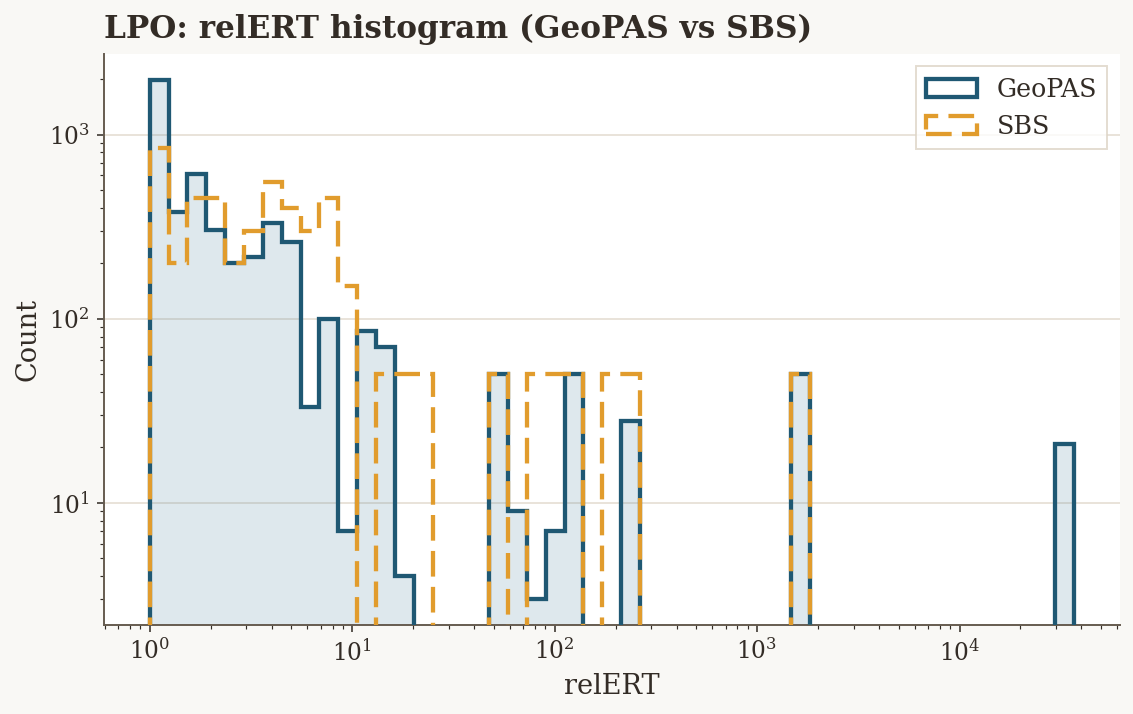

/data1/home/jw1017/AS_BBO_REBUILT/GeoPAS_v1/analysis_outputs/failure_analysis/scalelog_power_head2scalenorm_sigmoidlogs1.0_dual0_head2lw0.0_head2sw0.0_priorscalelog_power_lamprior0.5_tailscale1.0__aggregated_over_seeds__randomsplit17__res8__k32/fig_hist_relert_lpo_geopas_vs_sbs.svg


In [6]:
lpo_df = analysis_by_protocol["LPO"]
lpo_hist_bins = make_log_bins(lpo_df["as_score"].to_numpy(dtype=float), lpo_df["sbs_score"].to_numpy(dtype=float))
lpo_hist_groups, lpo_hist_group_order, lpo_hist_group_colors, lpo_hist_legend_title = resolve_histogram_grouping(
    lpo_df,
    hist_color_by,
)
fig_hist, ax_hist = plt.subplots(figsize=(8.2, 5.2), facecolor=FIGURE_FACE)
plot_histogram_comparison(
    ax_hist,
    lpo_df["as_score"].to_numpy(dtype=float),
    lpo_df["sbs_score"].to_numpy(dtype=float),
    bins=lpo_hist_bins,
    title="LPO: relERT histogram (GeoPAS vs SBS)",
    show_legend=True,
    count_scale=hist_count_scale,
    row_groups=lpo_hist_groups,
    group_order=lpo_hist_group_order,
    group_colors=lpo_hist_group_colors,
    group_target=hist_group_target,
    legend_title=lpo_hist_legend_title,
)
fig_hist.tight_layout()
fig_hist_path = config.output_dir / "fig_hist_relert_lpo_geopas_vs_sbs.svg"
fig_hist.savefig(fig_hist_path, bbox_inches="tight", facecolor=FIGURE_FACE)
plt.show()
print(fig_hist_path)

In [7]:
tail_quadrant_df = build_tail_quadrant_table(analysis_by_protocol, broadcast_tail_threshold)
tail_quadrant_df = tail_quadrant_df.sort_values(["threshold_label", "Protocol"]).reset_index(drop=True)
tail_quadrant_csv_path = save_dataframe(tail_quadrant_df, config.output_dir / "tail_quadrant_counts.csv")

rounded_tail_quadrant_df = tail_quadrant_df.copy()
rounded_tail_quadrant_df["threshold_value"] = rounded_tail_quadrant_df["threshold_value"].map(lambda value: round(float(value), 6))
# rounded_tail_quadrant_df["threshold_value"] = 12.477
rounded_tail_quadrant_df["fraction_non_tail"] = rounded_tail_quadrant_df["fraction_non_tail"].map(lambda value: round(float(value), 6))
rounded_tail_quadrant_df["geopas_only_tail_rate"] = rounded_tail_quadrant_df["geopas_only_tail_rate"].map(lambda value: round(float(value), 6))

print(f"Saved tail quadrant table to: {tail_quadrant_csv_path}")
rounded_tail_quadrant_df

Saved tail quadrant table to: /data1/home/jw1017/AS_BBO_REBUILT/GeoPAS_v1/analysis_outputs/failure_analysis/scalelog_power_head2scalenorm_sigmoidlogs1.0_dual0_head2lw0.0_head2sw0.0_priorscalelog_power_lamprior0.5_tailscale1.0__aggregated_over_seeds__randomsplit17__res8__k32/tail_quadrant_counts.csv


,Protocol,threshold_label,threshold_value,Neither,SBS only,Both,AS only,fraction_non_tail,geopas_only_tail_rate,geopas_only_outliers_zero
0,LIO,1000,1000.000000,4750,50,0,0,0.989583,0.000000,True
1,LPO,1000,1000.000000,4729,0,50,21,0.985208,0.004375,False
2,LIO,T,30.373417,4450,299,51,0,0.927083,0.000000,True
3,LPO,T,30.373417,4416,166,184,34,0.920000,0.007083,True


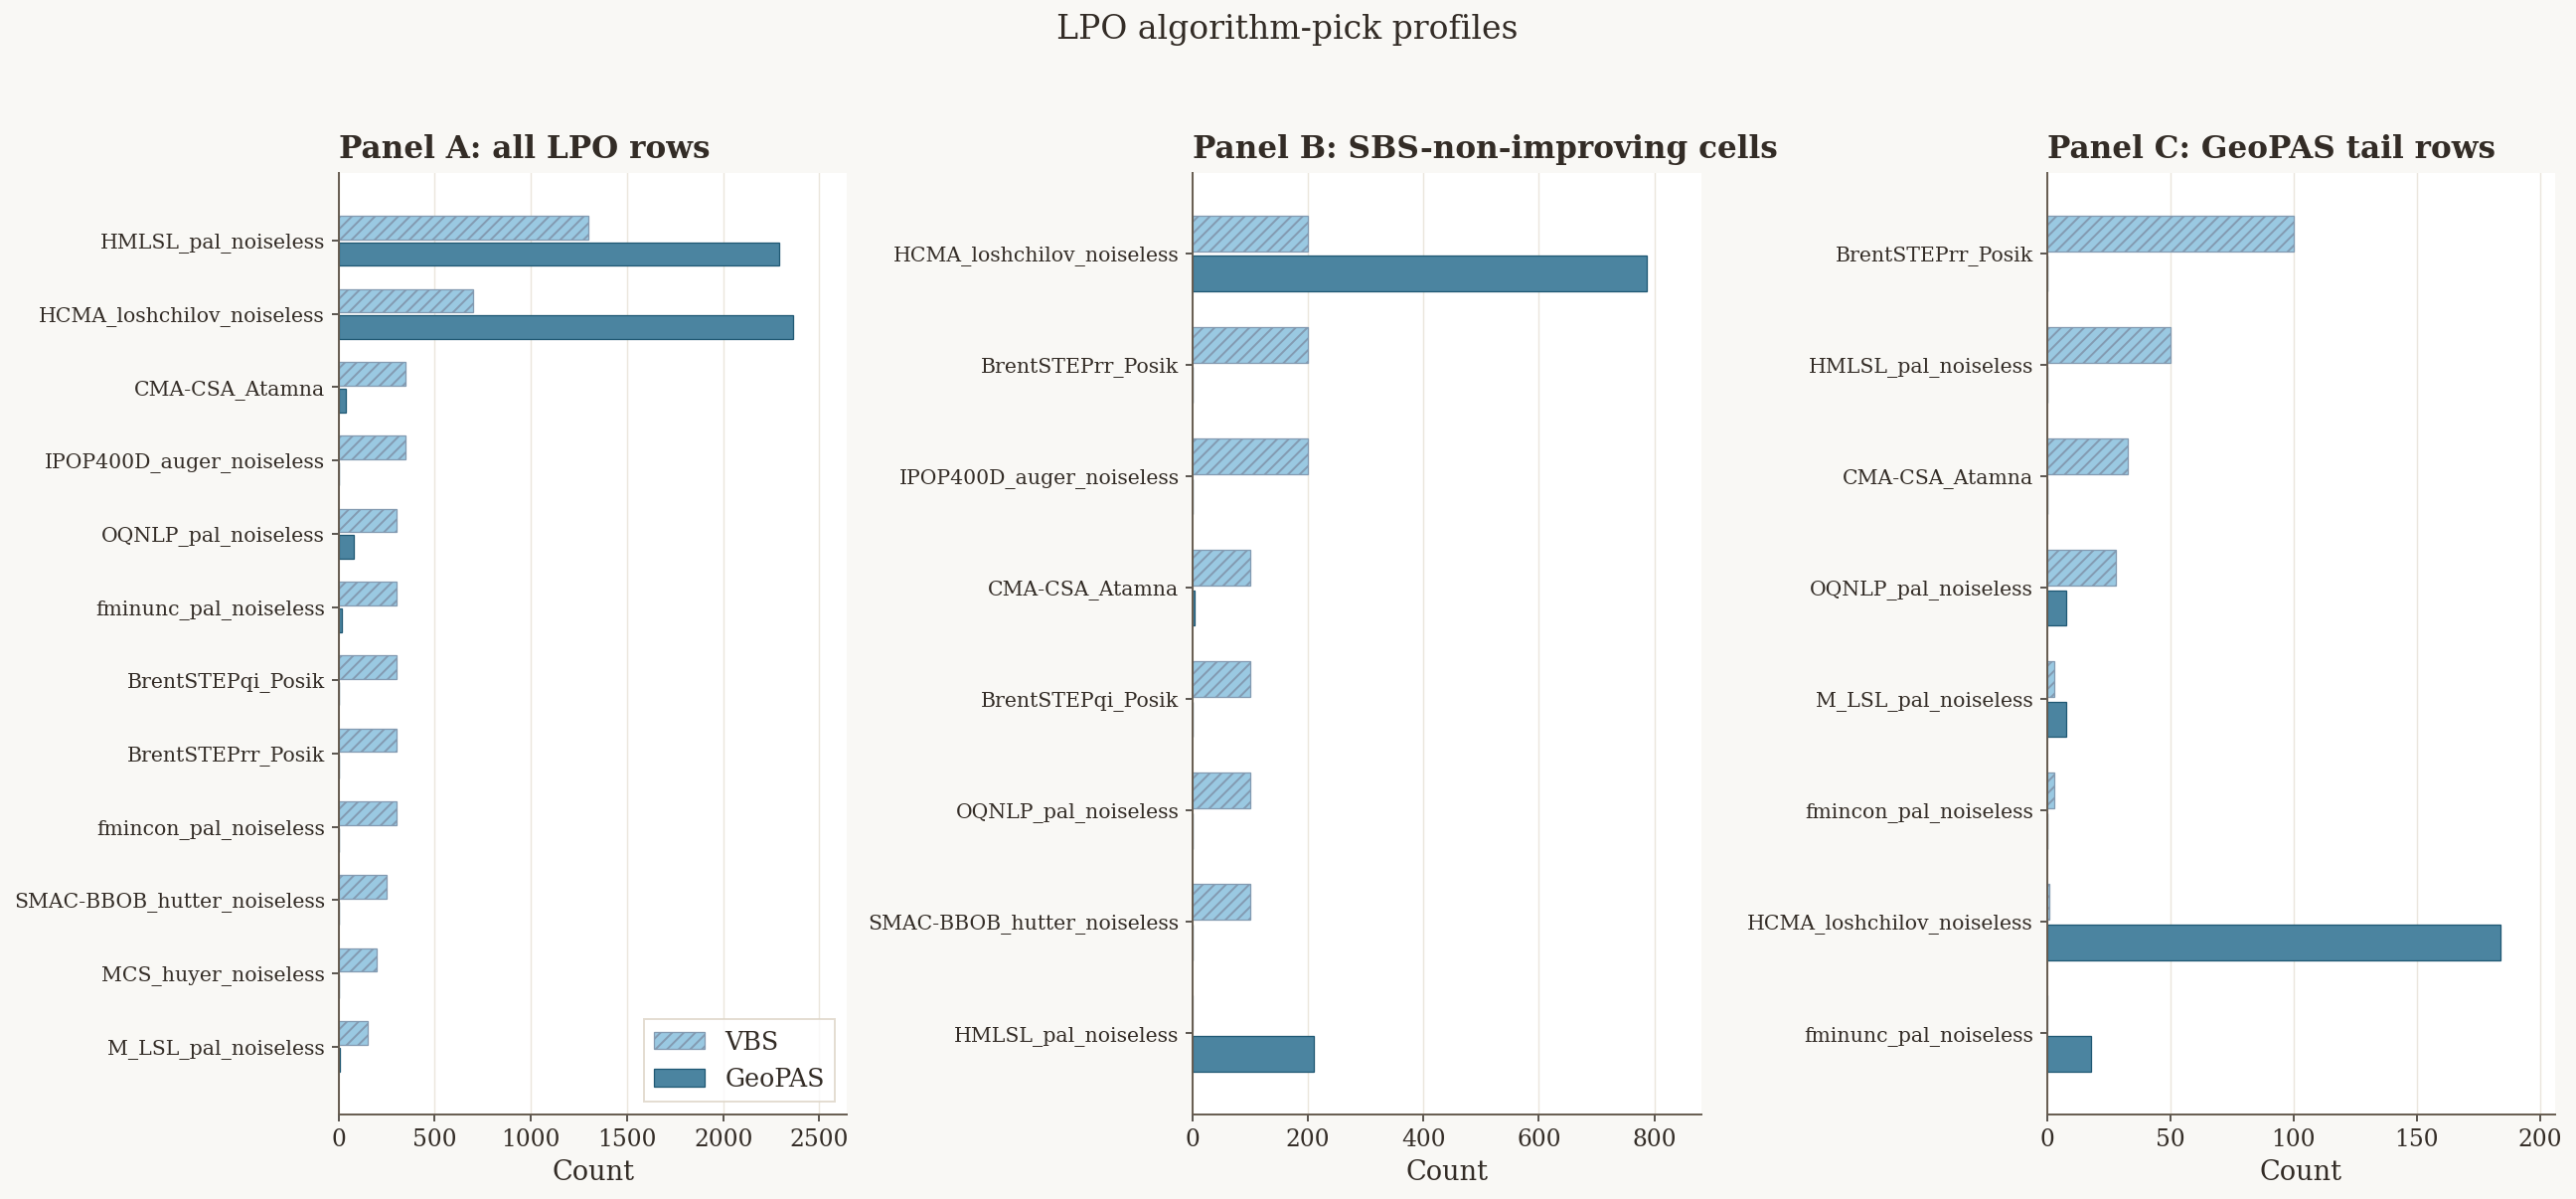

/data1/home/jw1017/AS_BBO_REBUILT/GeoPAS_v1/analysis_outputs/failure_analysis/scalelog_power_head2scalenorm_sigmoidlogs1.0_dual0_head2lw0.0_head2sw0.0_priorscalelog_power_lamprior0.5_tailscale1.0__aggregated_over_seeds__randomsplit17__res8__k32/fig_pickfreq_lpo_all_nonimproving_tail.svg


In [8]:
lpo_non_improving_df = subset_non_improving_rows(lpo_df, non_improving_cells)
lpo_tail_df = lpo_df.loc[lpo_df["as_tail_T"]].copy()

fig_pick, axes_pick = plt.subplots(1, 3, figsize=(18.6, 8.4), facecolor=FIGURE_FACE)
fig_pick.suptitle("LPO algorithm-pick profiles", fontsize=17, color=TEXT_COLOR, y=1.02)
plot_pick_frequency_panel(axes_pick[0], lpo_df, "Panel A: all LPO rows", show_legend=True)
plot_pick_frequency_panel(axes_pick[1], lpo_non_improving_df, "Panel B: SBS-non-improving cells", show_legend=False)
plot_pick_frequency_panel(axes_pick[2], lpo_tail_df, "Panel C: GeoPAS tail rows", show_legend=False)
fig_pick.tight_layout(rect=(0.0, 0.0, 1.0, 0.98))
fig_pick_path = config.output_dir / "fig_pickfreq_lpo_all_nonimproving_tail.svg"
fig_pick.savefig(fig_pick_path, bbox_inches="tight", facecolor=FIGURE_FACE)
plt.show()
print(fig_pick_path)

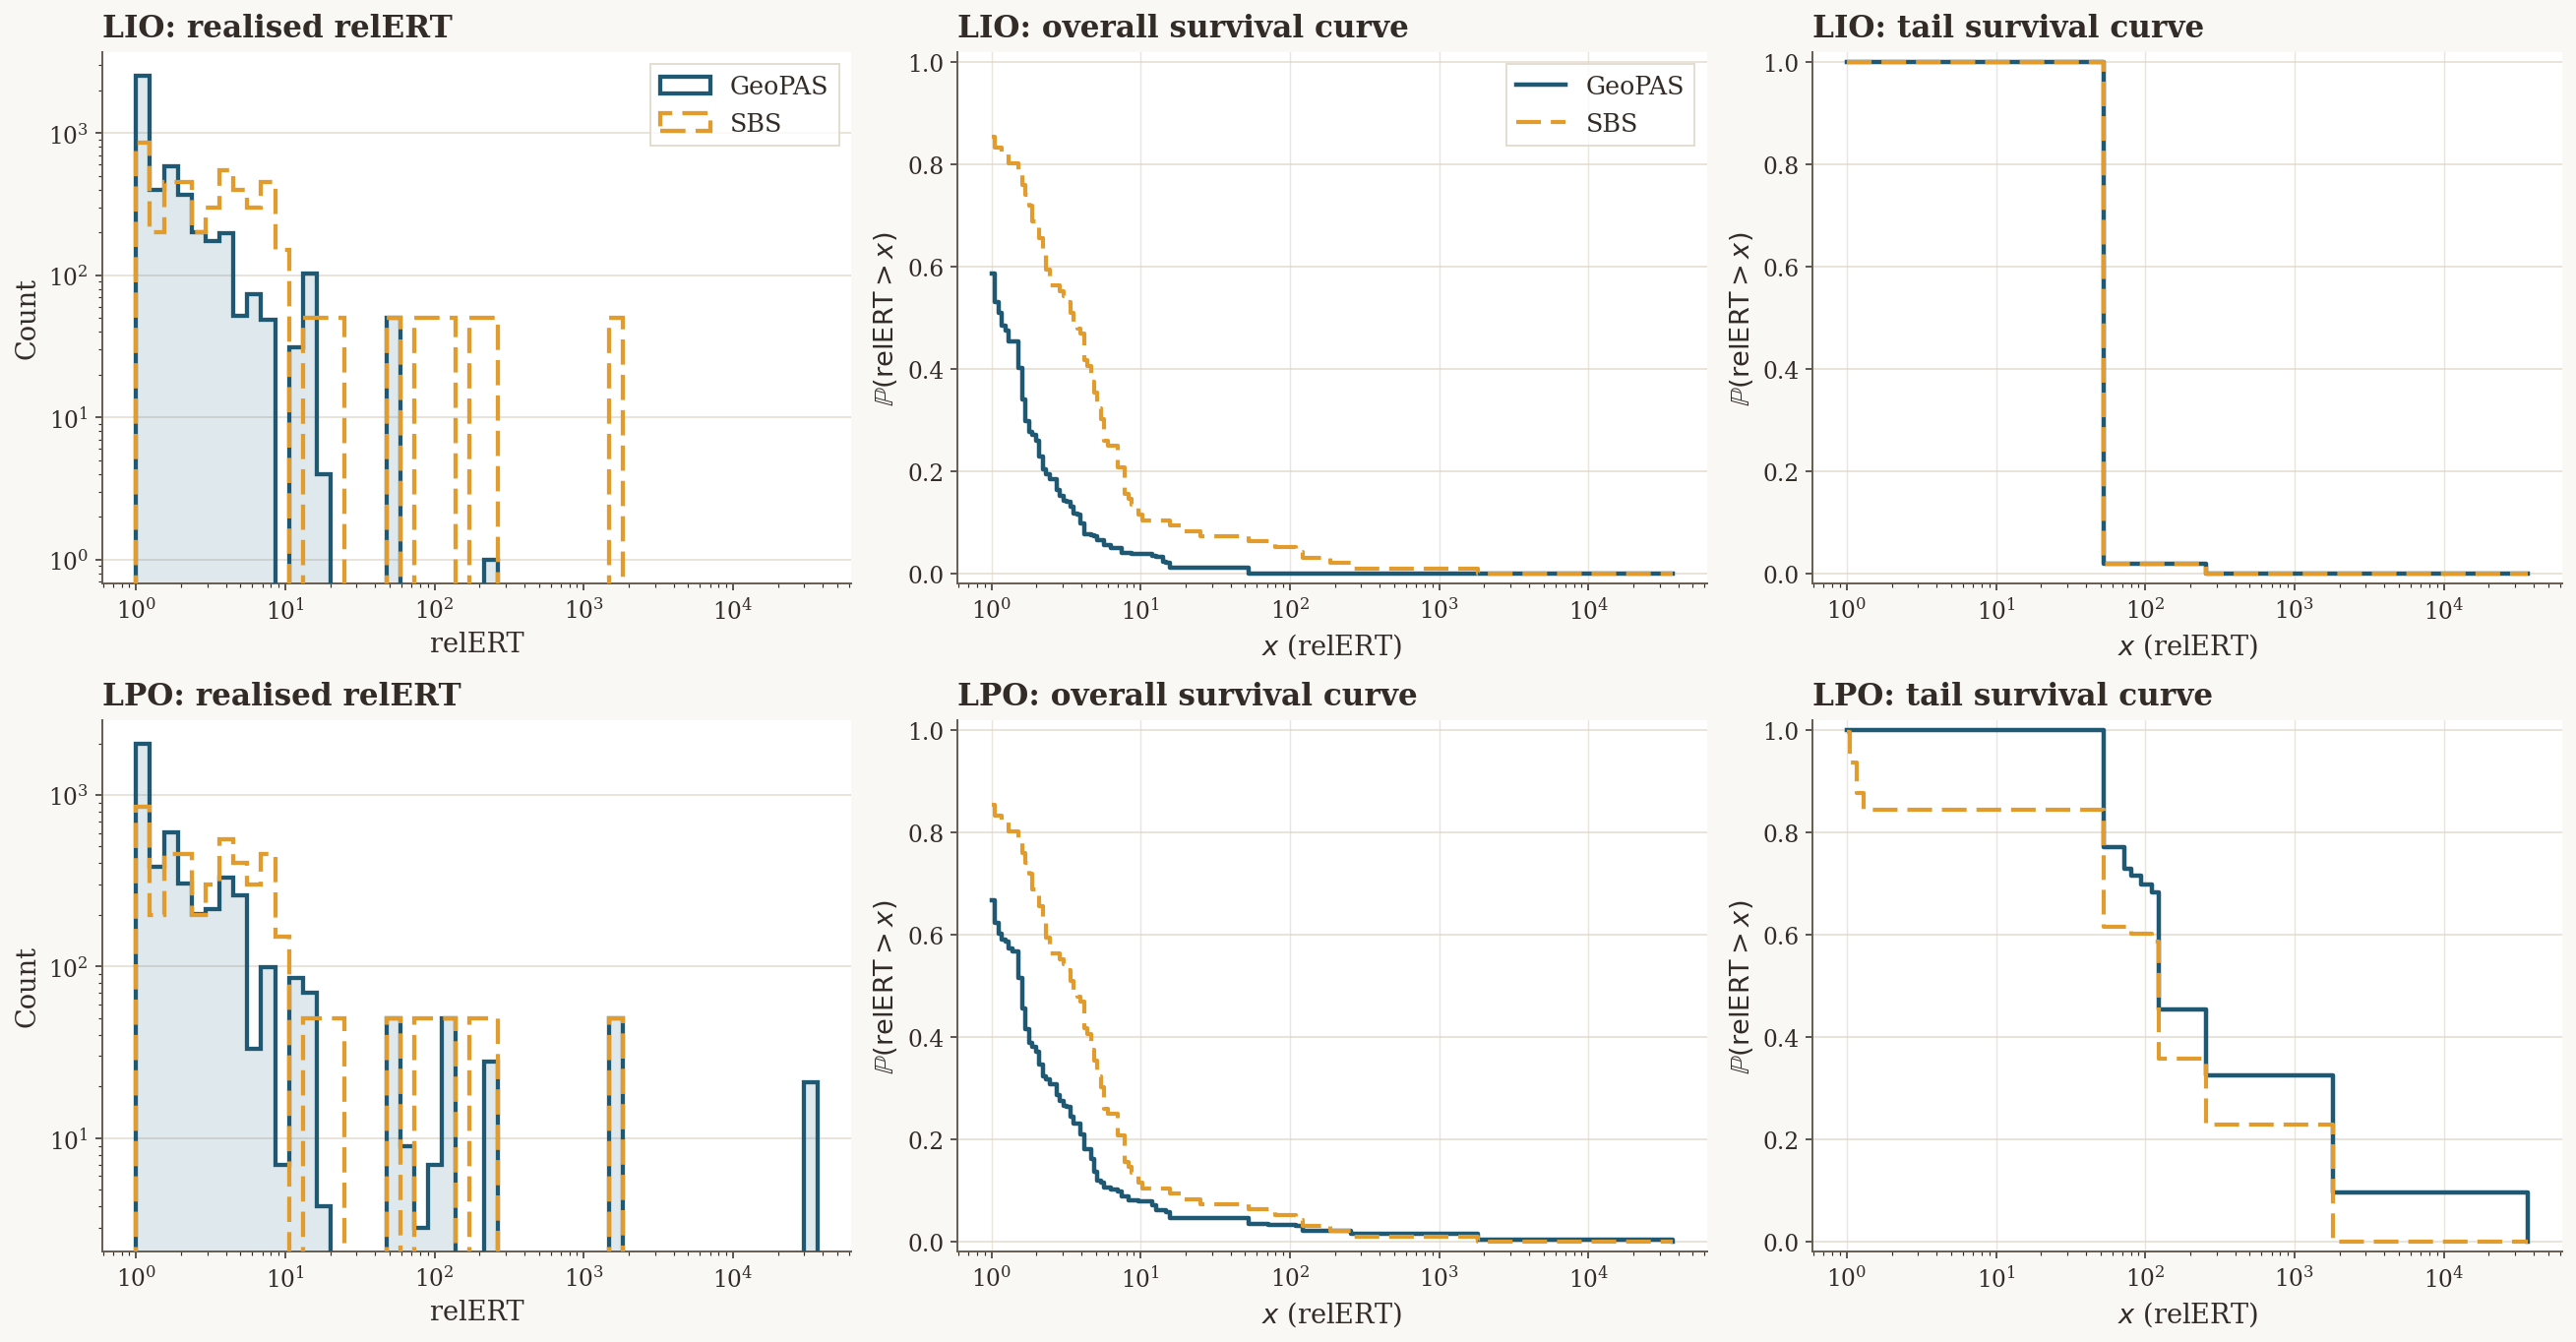

/data1/home/jw1017/AS_BBO_REBUILT/GeoPAS_v1/analysis_outputs/failure_analysis/scalelog_power_head2scalenorm_sigmoidlogs1.0_dual0_head2lw0.0_head2sw0.0_priorscalelog_power_lamprior0.5_tailscale1.0__aggregated_over_seeds__randomsplit17__res8__k32/fig_protocolwise_selection_distributions_and_pickfreqs.svg


In [9]:
shared_hist_bins = make_log_bins(
    *(protocol_df["as_score"].to_numpy(dtype=float) for protocol_df in analysis_by_protocol.values()),
    *(protocol_df["sbs_score"].to_numpy(dtype=float) for protocol_df in analysis_by_protocol.values()),
)
survival_grid = build_survival_grid(analysis_by_protocol)

fig_grid, axes_grid = plt.subplots(2, 3, figsize=(18.8, 10), facecolor=FIGURE_FACE)
# fig_grid.suptitle("Protocol-wise selection distributions and algorithm picks", fontsize=18, color=TEXT_COLOR, y=1.01)
for col_index, protocol in enumerate(config.protocols):
    protocol_df = analysis_by_protocol[protocol]
    non_improving_df = subset_non_improving_rows(protocol_df, non_improving_cells)
    tail_df = protocol_df.loc[protocol_df["as_tail_T"]].copy()
    hist_groups, hist_group_order, hist_group_colors, hist_legend_title = resolve_histogram_grouping(
        protocol_df,
        hist_color_by,
    )

    plot_histogram_comparison(
        axes_grid[col_index, 0],
        protocol_df["as_score"].to_numpy(dtype=float),
        protocol_df["sbs_score"].to_numpy(dtype=float),
        bins=shared_hist_bins,
        title=f"{protocol}: realised relERT",
        show_legend=(col_index == 0),
        count_scale=hist_count_scale,
        row_groups=hist_groups,
        group_order=hist_group_order,
        group_colors=hist_group_colors,
        group_target=hist_group_target,
        legend_title=hist_legend_title,
    )

    plot_survival_panel(axes_grid[col_index, 1], protocol_df, survival_grid, f"{protocol}: overall survival curve", show_legend=(col_index == 0))
    # plot_survival_panel(axes_grid[1, col_index], non_improving_df, survival_grid, f"{protocol}: non-improving cells", show_legend=False)
    plot_survival_panel(axes_grid[col_index, 2], tail_df, survival_grid, f"{protocol}: tail survival curve", show_legend=False)

fig_grid.tight_layout(rect=(0.0, 0.0, 1.0, 0.985))
fig_grid_path = config.output_dir / "fig_protocolwise_selection_distributions_and_pickfreqs.svg"
fig_grid.savefig(fig_grid_path, bbox_inches="tight", facecolor=FIGURE_FACE)
plt.show()
print(fig_grid_path)

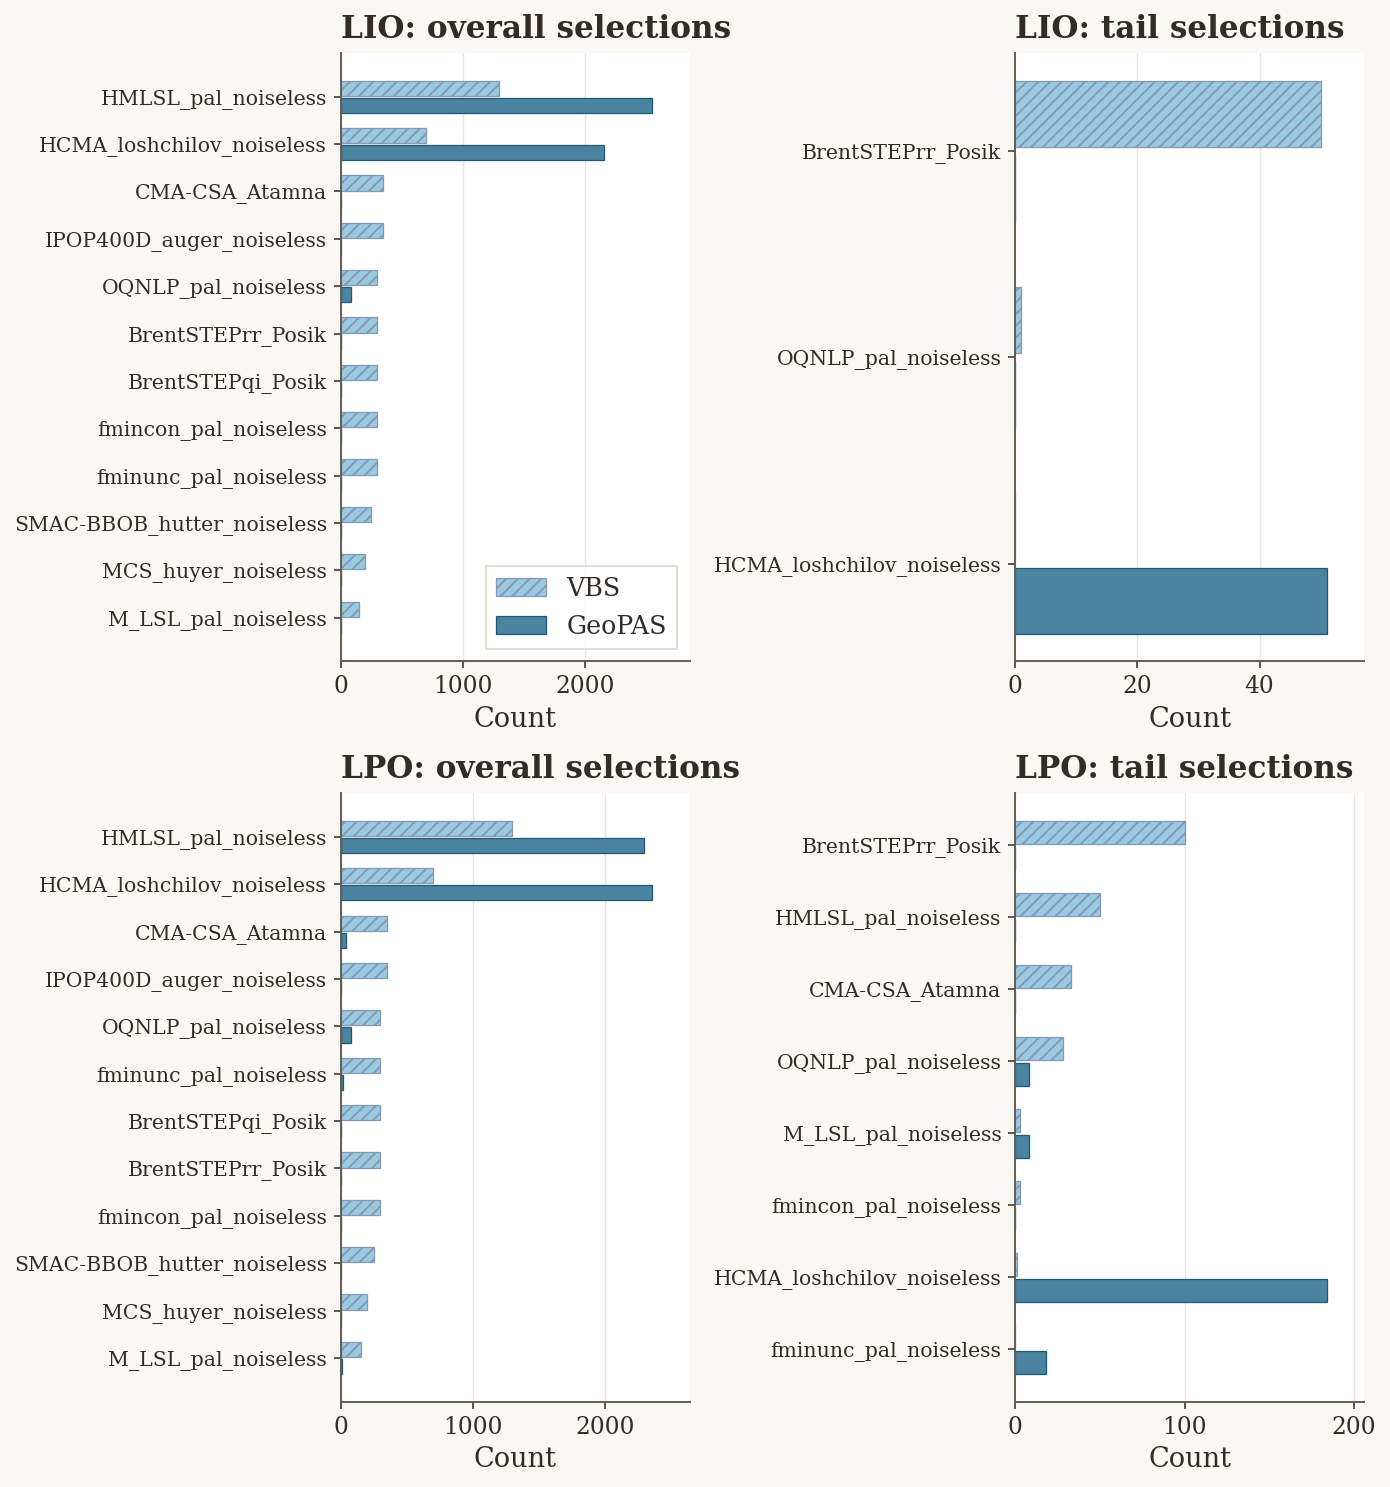

/data1/home/jw1017/AS_BBO_REBUILT/GeoPAS_v1/analysis_outputs/failure_analysis/scalelog_power_head2scalenorm_sigmoidlogs1.0_dual0_head2lw0.0_head2sw0.0_priorscalelog_power_lamprior0.5_tailscale1.0__aggregated_over_seeds__randomsplit17__res8__k32/fig_protocolwise_survival_curves.svg


In [10]:


fig_survival, axes_survival = plt.subplots(2, 2, figsize=(10, 11), facecolor=FIGURE_FACE)
# fig_survival.suptitle("Protocol-wise survival profiles of relERT", fontsize=18, color=TEXT_COLOR, y=0.995)
for col_index, protocol in enumerate(config.protocols):
    protocol_df = analysis_by_protocol[protocol]
    non_improving_df = subset_non_improving_rows(protocol_df, non_improving_cells)
    tail_df = protocol_df.loc[protocol_df["as_tail_T"]].copy()
    # tail_df = protocol_df.loc[protocol_df["as_tail_1000"]].copy()
    
    plot_pick_frequency_panel(axes_survival[col_index, 0], protocol_df, f"{protocol}: overall selections", show_legend=(col_index == 0))
    # plot_pick_frequency_panel(axes_grid[2, col_index], non_improving_df, f"{protocol}: non-improving cells", show_legend=False)
    plot_pick_frequency_panel(axes_survival[col_index, 1], tail_df, f"{protocol}: tail selections", show_legend=False)

fig_survival.tight_layout(rect=(0.0, 0.0, 1.0, 0.975))
fig_survival_path = config.output_dir / "fig_protocolwise_survival_curves.svg"
fig_survival.savefig(fig_survival_path, bbox_inches="tight", facecolor=FIGURE_FACE)
plt.show()
print(fig_survival_path)

## Validation

Two SBS conventions matter in this notebook:

1. The current pipeline reports SBS on the duplicated per-row evaluation population reconstructed from `preds_*.csv.gz`.
2. Older result files may still use the legacy 96-row SBS baseline from the raw label table.

The summary-table checks below rebuild both SBS conventions and then validate against whichever one matches the loaded `res_*.csv` target for each protocol. Current `lam_prior` pipeline outputs should match the duplicated per-row convention.

For aggregated-over-seeds runs, the root-level `preds_*.csv.gz` files already contain seed-averaged predictions, whereas the `res_*.csv` summaries are averages of per-seed result tables. Because solver selection happens before that averaging, `AS` comparisons from aggregated predictions are informational rather than exact targets at both protocol and cell level.

The Random protocol has one additional caveat: its fold partition is seeded by the training seed in the pipeline, so aggregated root-level predictions mix different fold assignments across seeds. As a result, `Random / Mean / SBS` is also informational at the aggregated-over-seeds level. The notebook therefore treats `SBS` validation as exact everywhere else, records the aggregate-prediction `AS` gaps and the aggregated `Random / Mean / SBS` gap separately, and only turns those gaps into hard failures when `config.strict_target_count_validation` is enabled.

In [11]:
effective_csv_compare_tol = max(config.csv_compare_tol, 1e-3)

summary_validation_frames = []
for protocol in config.protocols:
    for metric in ["Mean", "Median", "P90"]:
        for section in ["AS", "SBS"]:
            summary_validation_frames.append(
                compare_summary_tables(
                    observed_tables_by_protocol[protocol][metric][section],
                    result_tables_by_protocol[protocol][metric][section],
                    protocol=protocol,
                    metric=metric,
                    section=section,
                    tol=effective_csv_compare_tol,
                )
            )

summary_validation_df = pd.concat(summary_validation_frames, ignore_index=True)
protocol_level_validation_df = summary_validation_df.loc[
    (summary_validation_df["Problem Group"] == "all") & (summary_validation_df["Dim"] == "all")
].copy()
cell_level_validation_df = summary_validation_df.loc[
    (summary_validation_df["Problem Group"] != "all") & (summary_validation_df["Dim"] != "all")
].copy()

as_validation_gap_df = summary_validation_df.loc[
    summary_validation_df["Section"] == "AS"
].copy()
sbs_validation_df = summary_validation_df.loc[
    summary_validation_df["Section"] == "SBS"
].copy()
random_mean_sbs_gap_df = sbs_validation_df.loc[
    (sbs_validation_df["Protocol"] == "Random")
    & (sbs_validation_df["Metric"] == "Mean")
].copy()
remaining_sbs_validation_df = sbs_validation_df.drop(index=random_mean_sbs_gap_df.index).copy()

unexpected_sbs_validation_df = remaining_sbs_validation_df.loc[~remaining_sbs_validation_df["within_tol"]].copy()
unexpected_as_validation_df = as_validation_gap_df.loc[~as_validation_gap_df["within_tol"]].copy()
unexpected_random_mean_sbs_gap_df = random_mean_sbs_gap_df.loc[~random_mean_sbs_gap_df["within_tol"]].copy()

if not unexpected_sbs_validation_df.empty:
    raise RuntimeError(
        "Unexpected SBS summary validation failed "
        f"({len(unexpected_sbs_validation_df)} rows; max abs diff = {unexpected_sbs_validation_df['abs_diff'].max():.3f})."
    )

if config.strict_target_count_validation and not unexpected_as_validation_df.empty:
    raise RuntimeError(
        "Aggregated-prediction AS validation failed under strict mode "
        f"({len(unexpected_as_validation_df)} rows; max abs diff = {unexpected_as_validation_df['abs_diff'].max():.3f})."
    )

if config.strict_target_count_validation and not unexpected_random_mean_sbs_gap_df.empty:
    raise RuntimeError(
        "Aggregated Random Mean SBS validation failed under strict mode "
        f"({len(unexpected_random_mean_sbs_gap_df)} rows; max abs diff = {unexpected_random_mean_sbs_gap_df['abs_diff'].max():.3f})."
    )

save_dataframe(summary_validation_df, config.output_dir / "validation_summary_tables.csv")
save_dataframe(protocol_level_validation_df, config.output_dir / "validation_protocol_summary_tables.csv")
save_dataframe(cell_level_validation_df, config.output_dir / "validation_cell_summary_tables.csv")
save_dataframe(
    as_validation_gap_df,
    config.output_dir / "validation_summary_tables__aggregated_as_gap.csv",
)
save_dataframe(
    sbs_validation_df,
    config.output_dir / "validation_summary_tables__sbs.csv",
)
save_dataframe(
    random_mean_sbs_gap_df,
    config.output_dir / "validation_summary_tables__aggregated_random_mean_sbs_gap.csv",
)

print(f"Summary table compare tolerance: {effective_csv_compare_tol}")
print("SBS summary validation excluding aggregated Random Mean SBS: PASS")
if random_mean_sbs_gap_df.empty or random_mean_sbs_gap_df["within_tol"].all():
    print("Aggregated Random Mean SBS validation: PASS")
else:
    print(
        "Aggregated Random Mean SBS validation: "
        f"INFO -> {len(random_mean_sbs_gap_df)} rows differ; "
        f"max abs diff = {random_mean_sbs_gap_df['abs_diff'].max():.3f}"
    )
if as_validation_gap_df.empty or as_validation_gap_df["within_tol"].all():
    print("AS validation from aggregated preds: PASS")
else:
    print(
        "AS validation from aggregated preds: "
        f"INFO -> {len(as_validation_gap_df)} rows differ; "
        f"max abs diff = {as_validation_gap_df['abs_diff'].max():.3f}"
    )
print(f"SBS-non-improving subset: PASS -> {sorted(non_improving_cells)}")
print(f"Strict target count validation enabled: {config.strict_target_count_validation}")

protocol_level_validation_df

Summary table compare tolerance: 0.001
SBS summary validation excluding aggregated Random Mean SBS: PASS
Aggregated Random Mean SBS validation: PASS
AS validation from aggregated preds: INFO -> 180 rows differ; max abs diff = 12233.755
SBS-non-improving subset: PASS -> [('f1-f5', 5), ('f1-f5', 10), ('f15-f19', 3), ('f15-f19', 5)]
Strict target count validation enabled: False


,Protocol,Metric,Section,Problem Group,Dim,observed,expected,abs_diff,within_tol
29,LIO,Mean,AS,all,all,2.603,3.137,0.534,False
59,LIO,Mean,SBS,all,all,30.373,30.373,0.000,True
89,LIO,Median,AS,all,all,1.137,1.191,0.054,False
119,LIO,Median,SBS,all,all,3.438,3.438,0.000,True
149,LIO,P90,AS,all,all,3.853,3.960,0.107,False
179,LIO,P90,SBS,all,all,14.863,14.863,0.000,True
209,LPO,Mean,AS,all,all,184.798,200.051,15.253,False
239,LPO,Mean,SBS,all,all,30.373,30.373,0.000,True
269,LPO,Median,AS,all,all,1.542,1.585,0.043,False
299,LPO,Median,SBS,all,all,3.438,3.438,0.000,True


In [12]:
produced_artifacts = pd.DataFrame(
    {
        "artifact": sorted(path.name for path in config.output_dir.iterdir())
    }
)
produced_artifacts

,artifact
0,cell_summary_by_protocol.csv
1,fig_hist_relert_lpo_geopas_vs_sbs.svg
2,fig_pickfreq_lpo_all_nonimproving_tail.svg
3,fig_protocolwise_selection_distributions_and_p...
4,fig_protocolwise_survival_curves.svg
5,per_row_analysis__lio.csv.gz
6,per_row_analysis__lpo.csv.gz
7,protocol_level_summary.csv
8,sbs_non_improving_cells.csv
9,sbs_validation_style_by_protocol.csv
